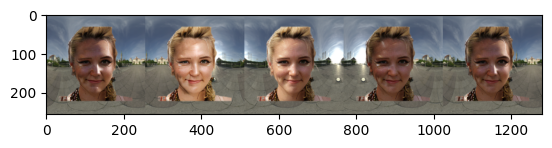

[[[121 132 143]
  [121 132 143]
  [121 132 143]
  ...
  [121 132 143]
  [121 132 143]
  [121 132 144]]

 [[117 127 141]
  [117 127 141]
  [117 128 141]
  ...
  [117 128 141]
  [117 128 141]
  [117 128 141]]

 [[115 127 139]
  [115 127 139]
  [115 127 139]
  ...
  [115 127 139]
  [115 127 139]
  [115 126 139]]

 ...

 [[115 115 103]
  [115 113 103]
  [115 113 102]
  ...
  [115 113 103]
  [115 113 102]
  [115 113 103]]

 [[113 111 102]
  [115 113 103]
  [117 113 103]
  ...
  [115 113 103]
  [117 113 104]
  [119 115 106]]

 [[125 122 111]
  [125 122 111]
  [125 122 111]
  ...
  [125 122 111]
  [125 122 111]
  [125 124 111]]]


AssertionError: 

In [ ]:
import numpy as np
import torch as th
import json, os, glob
import imageio
import cv2
import multiprocessing as mp
import matplotlib.pyplot as plt

# Azimuth = Axis 1
# method = ["neural_gaffer_azimuth", "difareli++_azimuth_color"]
method = ["neural_gaffer_azimuth"]
meta = json.load(open("/home/mint/Dev/DiFaReli/difareli-faster/visualize_scripts/TPAMI/MajorRevision/hdr/hdr.json"))
sample = json.load(open("/home/mint/Dev/DiFaReli/difareli-faster/experiment_scripts/TPAMI/sample_json/TPAMI_MajorRevision/all_rotateSH.json"))
out_dir = "./axis1_figure/"
os.makedirs(out_dir, exist_ok=True)

hdr_map = ["012_hdrmaps_com_free_2K", "064_hdrmaps_com_free_2K", "117_hdrmaps_com_free_2K", "125_hdrmaps_com_free_2K", "128_hdrmaps_com_free_2K"]

def blending_mask(img_path, mask_path, hdr_from_bg_path):
        mask = imageio.v2.imread(mask_path) / 255.0 #[256, 256]
        blurred_mask = cv2.GaussianBlur(mask, (3, 3), 0)
        # Apply erosion
        kernel = np.ones((3,3),np.uint8)
        eroded_mask = cv2.erode(blurred_mask, kernel, iterations = 1)
        mask = eroded_mask [..., np.newaxis]
        
        img = imageio.v2.imread(img_path).astype(np.float32) / 255.0
        bg = imageio.v2.imread(hdr_from_bg_path).astype(np.float32) / 255.0
        # alpha blending
        out = img * mask + bg * (1 - mask)
        out = (out * 255).astype(np.uint8)
        return out


for pid, dat in sample['pair'].items():
    src = dat['src']
    dst = dat['dst']
    
    for hdr in hdr_map[:1]:
        for m in method:
            if m == "neural_gaffer_azimuth":
                path = meta[m]['res_dir']
                frames = sorted(glob.glob(f"{path}/{src.split('.')[0]}/{hdr}/pred_*.png"))
                target_hdr = sorted(glob.glob(f"{path}/{src.split('.')[0]}/{hdr}/target_*.png"))
                mask = f"/data/mint/DPM_Dataset/Dataset_For_Baseline/neural_gaffer/input_subject/preprocessed/mask/{src.split('.')[0]}.png"
            elif m == "difareli++_azimuth_color":
                path = meta[m]['res_dir']
                frames = sorted(glob.glob(f"{path}/{hdr}/src={src}/dst={dst}/n_frames=60/res_frame*.png"))[1:]
                target_hdr = sorted(glob.glob(f"{meta['neural_gaffer_azimuth']['res_dir']}/{src.split('.')[0]}/{hdr}/target_*.png"))
                mask = None #TODO: Add loading foreground mask
                
                
            frames = [frames[i] for i in [0, 15, 30, 45, 58]]
            target_hdr = [target_hdr[i] for i in [0, 15, 30, 45, 58]]
            # Reuse the target hdr as background for difareli++ too
            
            with mp.Pool(5) as p:
                out_frames = p.starmap(blending_mask, (zip(frames, [mask]*5, target_hdr)))
            out_frames = np.concatenate(out_frames, axis=1)
            plt.imshow(out_frames)
            plt.show()
            print(out_frames)
            assert False
            
            
            